## Original podracing model

In [1]:
using JuMP, Gurobi

m = Model(solver=GurobiSolver(OutputFlag=0))

T = 50                # length of time horizon
@variable(m, x[1:T])    # resulting position
@variable(m, v[1:T])    # resulting velocity
@variable(m, u[1:T-1])  # thruster input

# constraint on start and end positions and velocities
@constraint(m, x[1] == 0)
@constraint(m, v[1] == 0)
@constraint(m, x[T] == 100)
@constraint(m, v[T] == 0)

# satisfy the dynamics
for i = 1:T-1
    @constraint(m, x[i+1] == x[i] + v[i])
    @constraint(m, v[i+1] == v[i] + u[i])
end

# minimize 2-norm
@objective(m, Min, sum(u.^2) )

solve(m)
uopt = getvalue(u);

## Plotting the thruster inputs

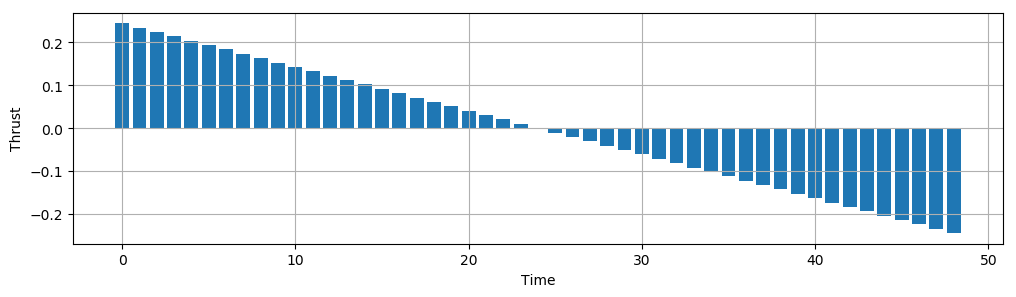

In [2]:
using PyPlot
figure(figsize=(12,3))
bar( 0:T-2, uopt );
xlabel("Time"); ylabel("Thrust"); grid()


## More comact podracing model

In [4]:
using JuMP

T = 50      # length of time horizon

m = Model(solver=GurobiSolver(OutputFlag=0))

@variable(m, u[1:T-1])  # thruster input

A = [(48:-1:0)'; ones(1,49)]
b = [100; 0]

@constraint(m, A*u .== b)

# 1-norm
@variable(m, t[1:T-1])
@constraint(m, u .<= t )
@constraint(m, -t .<= u )

# ∞-norm
@variable(m, r)
@constraint(m, u .<= r )
@constraint(m, -r .<= u )

# case = :inf_one
λ = 1
uopt = Dict()
for case in [:two, :one, :inf, :two_one, :two_inf, :inf_one, :everything]
    if case == :two
        @objective(m, Min, sum(u.^2))
    elseif case == :one
        @objective(m, Min, sum(t))
    elseif case == :inf
        @objective(m, Min, r)
    elseif case == :two_one
        @objective(m, Min, sum(u.^2) + λ*sum(t))  # lasso
    elseif case == :two_inf
        @objective(m, Min, sum(u.^2) + λ*r)  # L-inf regularization
    elseif case == :inf_one
        @objective(m, Min, r + λ*sum(t))
    elseif case == :everything
        @objective(m, Min, sum(u.^2) + sum(t) + r)
    end

    solve(m)
    println(case)
    println(getobjectivevalue(m))
    uopt[case] = getvalue(u);
end


two
1.0204081632653064
one
4.166666666666667
inf
0.16666666666666666
two_one
6.198235726956244
two_inf
1.2352473317175447
inf_one
4.999999999999999
everything
6.549499412526227


## Plot thruster input

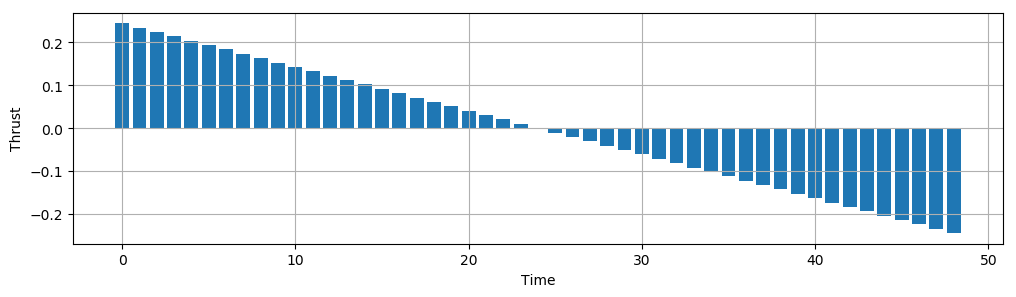

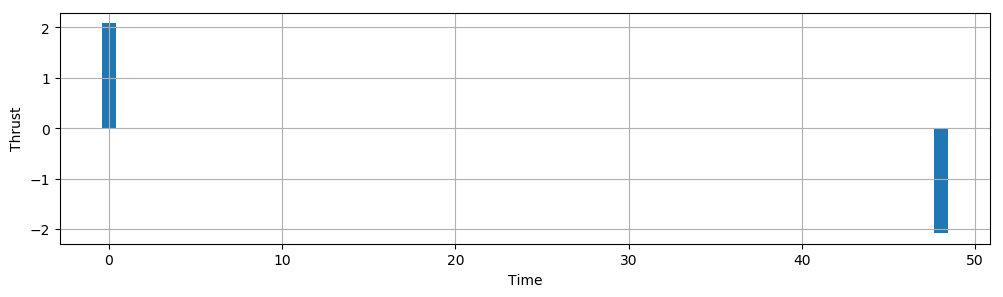

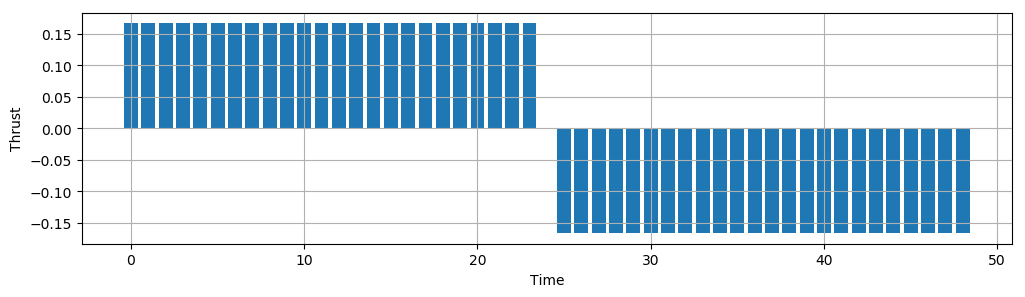

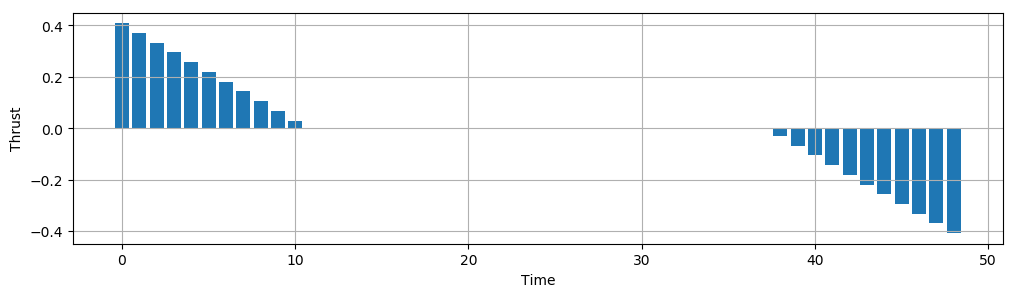

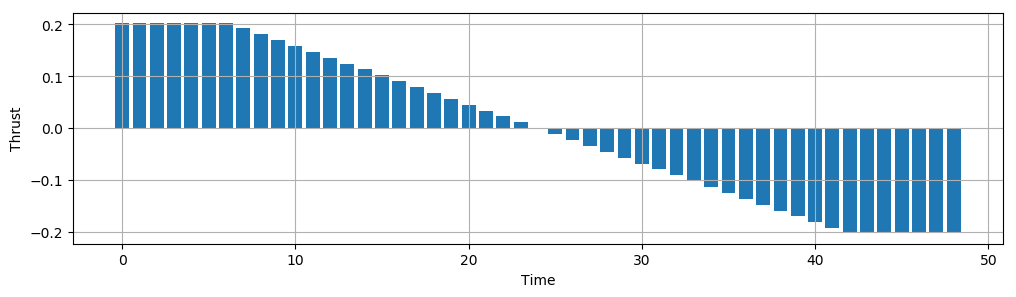

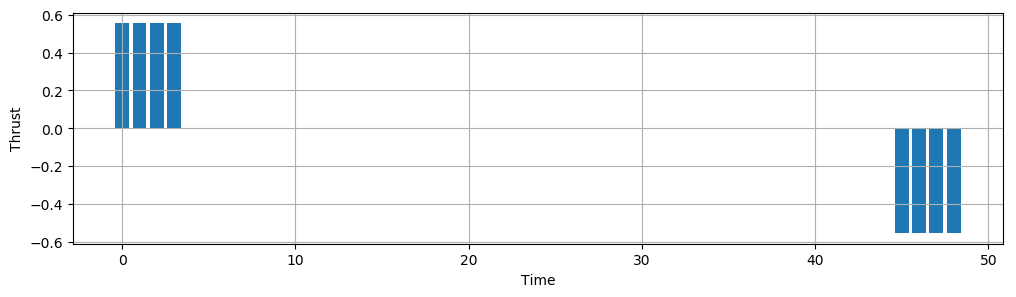

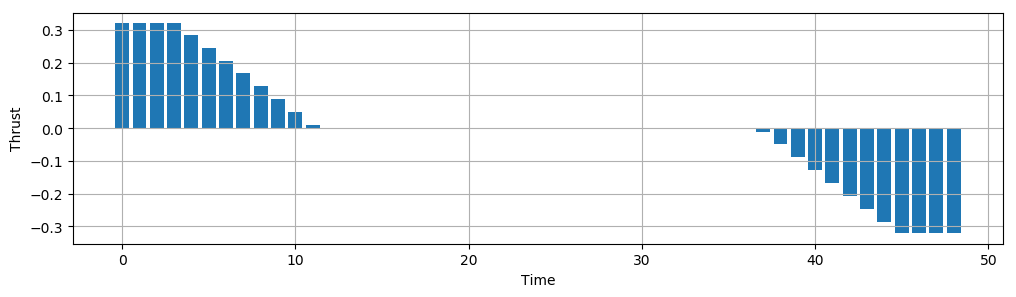

In [3]:
using PyPlot
for case in [:two, :one, :inf, :two_one, :two_inf, :inf_one, :everything]

    figure(figsize=(12,3))
    bar( 0:T-2, uopt[case] );
    xlabel("Time"); ylabel("Thrust"); grid()
end